<a href="https://colab.research.google.com/github/gauravpatra03-sketch/Deep-Learning/blob/main/GenAI_Week2_Ex1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Types of encoders:
1. Shallow Autoencoder
2. Deep Autoencoder
3. Sparse Autoencoder
4. Denoising Autoencoder

Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model

Load Dataset

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype("float32")/255.
x_test = x_test.astype("float32")/255.

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

print(x_train.shape)
print(x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 784)
(10000, 784)


1. Shallow Encoder

In [3]:
input_img=Input(shape=(784,))

encoded=Dense(64, activation='relu')(input_img)

decoded=Dense(784, activation='sigmoid')(encoded)

shallow_ae=Model(input_img, decoded)

shallow_ae.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

shallow_ae.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 784)            │        50,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,200 (395.31 KB)

 Trainable params: 101,200 (395.31 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
history=shallow_ae.fit(x_train,x_train,epochs=5,batch_size=256,shuffle=True,validation_data=(x_test,x_test))

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.2457 - val_loss: 0.1606
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.1422 - val_loss: 0.1257
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1178 - val_loss: 0.1084
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1039 - val_loss: 0.0975
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0947 - val_loss: 0.0900


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


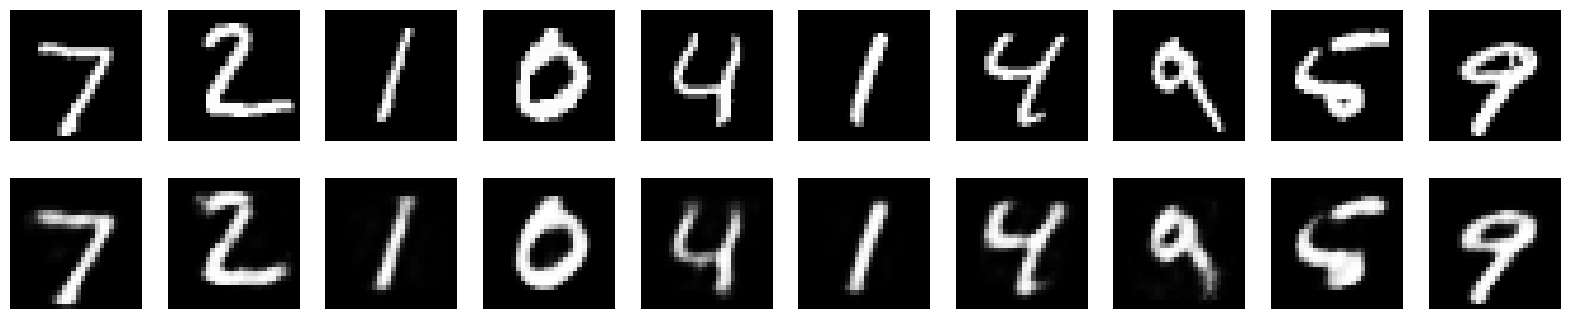

In [7]:
decoded_imgs=shallow_ae.predict(x_test)

n=10

plt.figure(figsize=(20,4))
for i in range(n):
  ax=plt.subplot(2,n,i+1)
  plt.imshow(x_test[i].reshape(28,28), cmap='gray')
  plt.axis('off')

  ax=plt.subplot(2,n,i+1+n)
  plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
  plt.axis('off')

plt.show()

2. Deep Encoder

In [10]:
input_img=Input(shape=(784,))

encoded=Dense(256, activation='relu')(input_img)
encoded=Dense(128, activation='relu')(encoded)
encoded=Dense(64, activation='relu')(encoded)

decoded=Dense(128, activation='relu')(encoded)
decoded=Dense(256, activation='relu')(decoded)
decoded=Dense(784, activation='sigmoid')(decoded)

deep_ae=Model(input_img, decoded)

deep_ae.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

deep_ae.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 484,944 (1.85 MB)

 Trainable params: 484,944 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
deep_ae.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=256,
    validation_data=(x_test,x_test)
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - loss: 0.2089 - val_loss: 0.1343
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.1209 - val_loss: 0.1098
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 0.1063 - val_loss: 0.1008
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0991 - val_loss: 0.0955
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0949 - val_loss: 0.0917


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


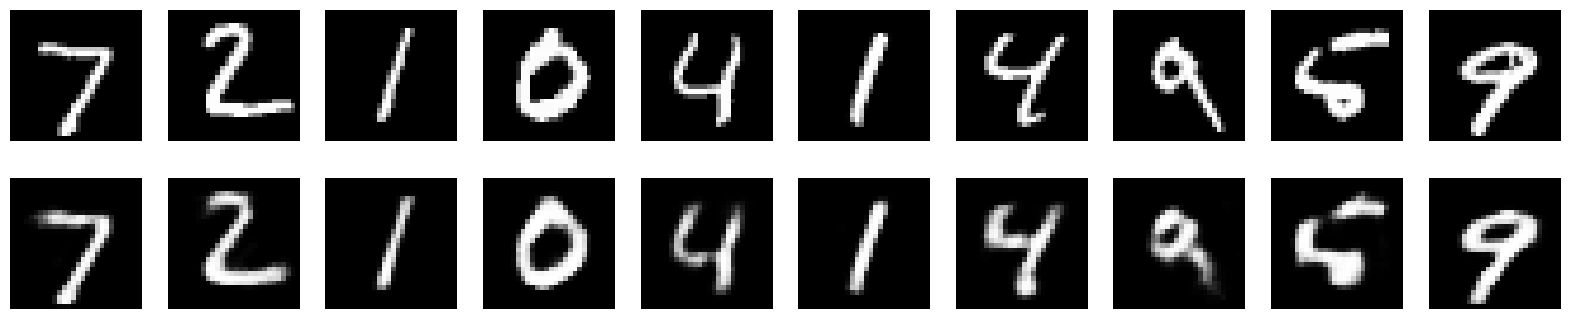

In [12]:
decoded_imgs=deep_ae.predict(x_test)

plt.figure(figsize=(20,4))

for i in range(10):

  ax=plt.subplot(2,10,i+1)
  plt.imshow(x_test[i].reshape(28,28), cmap='gray')
  plt.axis('off')

  ax=plt.subplot(2,10,i+11)
  plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
  plt.axis('off')

plt.show()

3. Sparse Autoencoder

In [15]:
from tensorflow.keras import regularizers

input_img=Input(shape=(784,))

encoded=Dense(64, activation='relu', activity_regularizer=regularizers.l1(1e-4))(input_img)

decoded=Dense(784, activation='sigmoid')(encoded)

sparse_ae=Model(input_img, decoded)

sparse_ae.compile(optimizer='adam',loss='binary_crossentropy')

sparse_ae.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 784)            │        50,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,200 (395.31 KB)

 Trainable params: 101,200 (395.31 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
sparse_ae.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=256,
    validation_data=(x_test,x_test)
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.6586 - val_loss: 0.6155
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.5832 - val_loss: 0.5535
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.5274 - val_loss: 0.5038
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.4827 - val_loss: 0.4637
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.4466 - val_loss: 0.4314


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


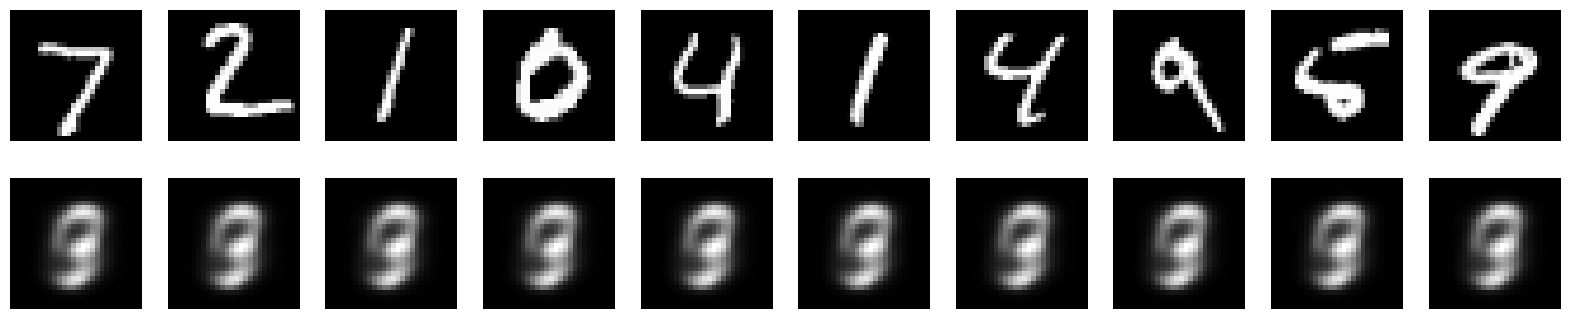

In [17]:
decoded_imgs=sparse_ae.predict(x_test)

plt.figure(figsize=(20,4))

for i in range(10):

  ax=plt.subplot(2,10,i+1)
  plt.imshow(x_test[i].reshape(28,28), cmap='gray')
  plt.axis('off')

  ax=plt.subplot(2,10,i+11)
  plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
  plt.axis('off')

plt.show()

4. Denoising Autoencoder

In [20]:
noise_factor=0.5

x_train_noisy=x_train+noise_factor*np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy=x_test+noise_factor*np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_train_noisy=np.clip(x_train_noisy,0.,1.)
x_test_noisy=np.clip(x_test_noisy,0.,1.)

In [21]:
input_img=Input(shape=(784,))

encoded=Dense(128, activation='relu')(input_img)
encoded=Dense(64, activation='relu')(encoded)

decoded=Dense(128, activation='relu')(encoded)
decoded=Dense(784, activation='sigmoid')(decoded)

denoising_ae=Model(input_img, decoded)

denoising_ae.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

In [22]:
denoising_ae.fit(
    x_train_noisy,
    x_train,
    epochs=5,
    batch_size=256,
    validation_data=(x_test_noisy,x_test)
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - loss: 0.2512 - val_loss: 0.1837
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1683 - val_loss: 0.1541
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1496 - val_loss: 0.1433
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1409 - val_loss: 0.1377
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1353 - val_loss: 0.1321


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


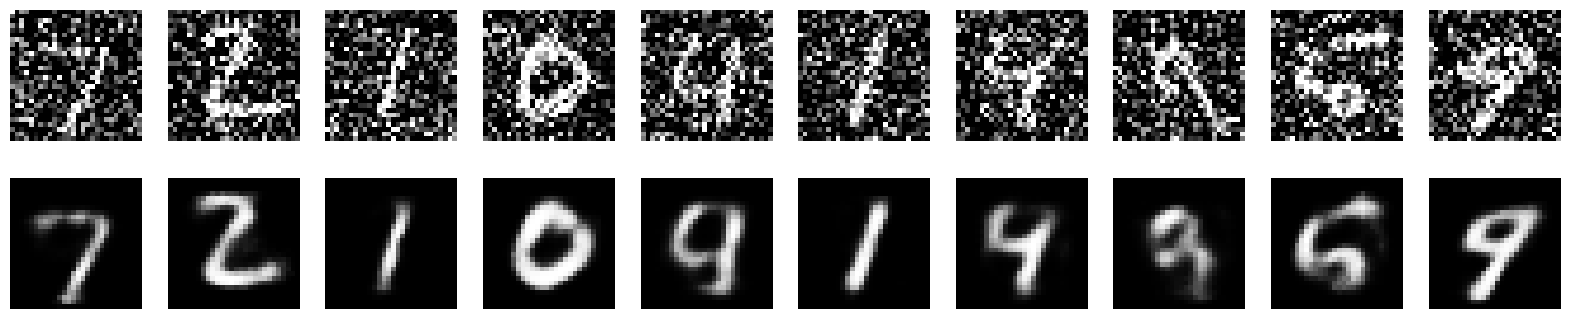

In [23]:
decoded_imgs=denoising_ae.predict(x_test_noisy)

plt.figure(figsize=(20,4))

for i in range(10):

  ax=plt.subplot(2,10,i+1)
  plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
  plt.axis('off')

  ax=plt.subplot(2,10,i+11)
  plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
  plt.axis('off')

plt.show()